In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
df = pd.read_csv("monthly_coal_full_data.csv")
df['YYYYMM'] = pd.to_datetime(df['YYYYMM'], format="%Y%m")
df['year'] = df['YYYYMM'].dt.year
df

,YYYYMM,National coal production,Lignite production,CIL production,SCCL production,Net Imports,Power station stocks,Consumption: All stations,CIL despatches,year
0,1999-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999
1,1999-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999
2,1999-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999
3,1999-04-01,20.230,2.093,17.420,NaN,NaN,NaN,NaN,21.460,1999
4,1999-05-01,21.809,1.804,18.931,NaN,NaN,NaN,NaN,22.355,1999
...,...,...,...,...,...,...,...,...,...,...
318,2025-07-01,64.860,3.300,46.400,4.20,21.152790,54.182513,70.921895,53.700,2025
319,2025-08-01,69.870,3.000,50.400,4.00,19.245101,51.284240,69.872405,56.700,2025
320,2025-09-01,68.180,2.780,48.970,3.70,18.104826,46.669408,68.490255,53.560,2025
321,2025-10-01,77.430,3.040,56.400,4.74,21.005397,48.228309,65.877932,58.300,2025


In [3]:
df.columns

Index(['YYYYMM', 'National coal production', 'Lignite production',
       'CIL production', 'SCCL production', 'Net Imports',
       'Power station stocks', 'Consumption: All stations', 'CIL despatches',
       'year'],
      dtype='object')

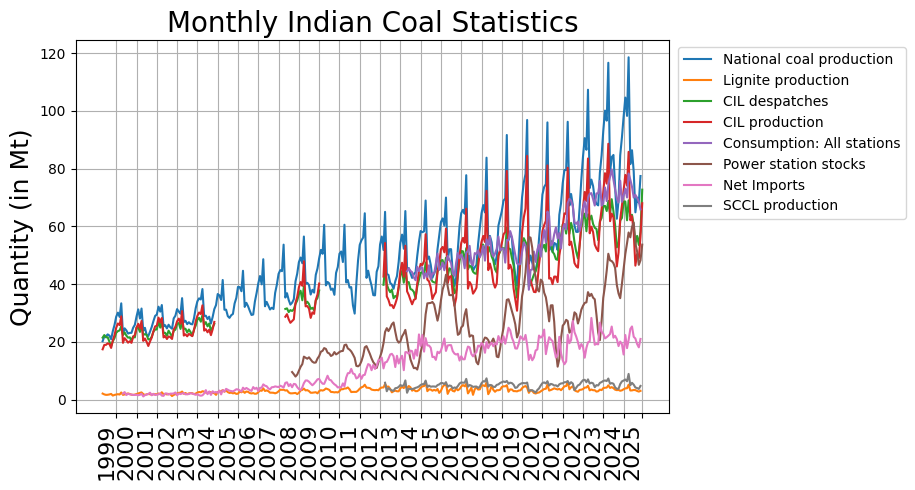

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(df['YYYYMM'],df['National coal production'], label='National coal production')
plt.plot(df['YYYYMM'],df['Lignite production'], label='Lignite production')
plt.plot(df['YYYYMM'],df['CIL despatches'], label='CIL despatches')
plt.plot(df['YYYYMM'],df['CIL production'], label='CIL production')
plt.plot(df['YYYYMM'],df['Consumption: All stations'], label='Consumption: All stations')
plt.plot(df['YYYYMM'],df['Power station stocks'], label='Power station stocks')
plt.plot(df['YYYYMM'],df['Net Imports'], label='Net Imports')
plt.plot(df['YYYYMM'],df['SCCL production'], label='SCCL production')

ticks = [i for _,i in enumerate(df['YYYYMM']) if (_+1)%12==0]
labels = df['YYYYMM'].dt.year.unique()
if len(labels)>len(ticks):
    ticks.append(list(df['YYYYMM'])[-1])
plt.xticks(ticks=ticks,
           labels = labels,
          rotation='vertical',ha="right",
          fontsize=16)
# Remove both x and y tick marks
#plt.tick_params(axis='both', which='both', length=0)
plt.title('Monthly Indian Coal Statistics', fontsize=20)
plt.ylabel('Quantity (in Mt)', fontsize=18)
plt.grid()
plt.legend(loc='upper right',bbox_to_anchor=(1.41, 1))
plt.tight_layout()
plt.savefig('monthly_india_coal_stats.png',dpi=300)

In [5]:
df_yearly = df.groupby('year')[['National coal production', 'Lignite production',
       'CIL production', 'SCCL production', 'Net Imports',
       'Power station stocks', 'Consumption: All stations', 'CIL despatches']].sum().reset_index()

In [6]:
df_yearly

,year,National coal production,Lignite production,CIL production,SCCL production,Net Imports,Power station stocks,Consumption: All stations,CIL despatches
0,1999,207.920,15.767,179.664,0.000,0.000000,0.000000,0.000000,190.220
1,2000,312.094,22.703,271.115,0.000,16.846659,0.000000,0.000000,272.717
2,2001,318.413,23.467,274.363,0.000,20.783147,0.000000,0.000000,277.390
3,2002,335.214,22.893,289.051,0.000,22.874887,0.000000,0.000000,290.394
4,2003,348.554,26.798,298.934,0.000,23.758330,0.000000,0.000000,297.690
5,2004,378.289,29.383,261.796,0.000,26.378473,0.000000,0.000000,264.218
6,2005,397.905,30.904,0.000,0.000,37.284759,0.000000,0.000000,0.000
7,2006,419.580,29.419,0.000,0.000,42.881207,0.000000,0.000000,0.000
8,2007,444.737,33.847,0.000,0.000,52.371742,0.000000,0.000000,0.000
9,2008,483.054,32.316,275.700,0.000,58.419968,44.988162,0.000000,290.200


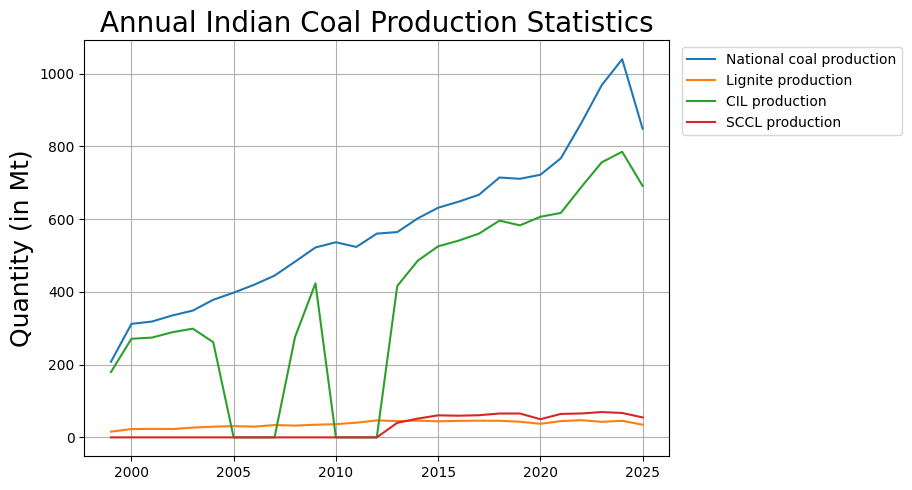

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(df_yearly['year'],df_yearly['National coal production'], label='National coal production')
plt.plot(df_yearly['year'],df_yearly['Lignite production'], label='Lignite production')
#plt.plot(df_yearly['year'],df_yearly['CIL despatches'], label='CIL despatches')
plt.plot(df_yearly['year'],df_yearly['CIL production'], label='CIL production')
#plt.plot(df_yearly['year'],df_yearly['Consumption: All stations'], label='Consumption: All stations')
#plt.plot(df_yearly['year'],df_yearly['Power station stocks'], label='Power station stocks')
#plt.plot(df_yearly['year'],df_yearly['Net Imports'], label='Net Imports')
plt.plot(df_yearly['year'],df_yearly['SCCL production'], label='SCCL production')

# plt.xticks(ticks=ticks,
#            labels = labels,
#           rotation='vertical',ha="right",
#           fontsize=16)
# Remove both x and y tick marks
#plt.tick_params(axis='both', which='both', length=0)
plt.title('Annual Indian Coal Production Statistics', fontsize=20)
plt.ylabel('Quantity (in Mt)', fontsize=18)
plt.grid()
plt.legend(loc='upper right',bbox_to_anchor=(1.41, 1))
plt.tight_layout()
#plt.show()
plt.savefig('annual_coal_production.png',dpi=300)

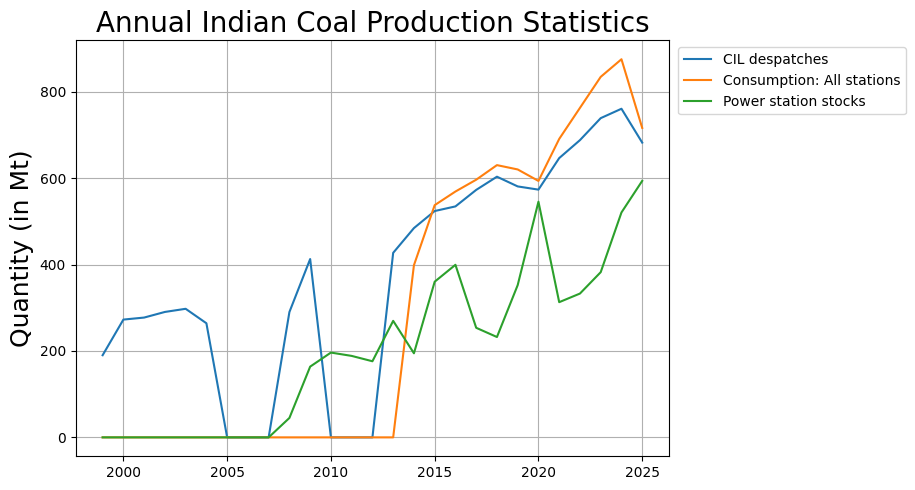

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(df_yearly['year'],df_yearly['CIL despatches'], label='CIL despatches')
plt.plot(df_yearly['year'],df_yearly['Consumption: All stations'], label='Consumption: All stations')
plt.plot(df_yearly['year'],df_yearly['Power station stocks'], label='Power station stocks')
#plt.plot(df_yearly['year'],df_yearly['Net Imports'], label='Net Imports')

# plt.xticks(ticks=ticks,
#            labels = labels,
#           rotation='vertical',ha="right",
#           fontsize=16)
# Remove both x and y tick marks
#plt.tick_params(axis='both', which='both', length=0)
plt.title('Annual Indian Coal Production Statistics', fontsize=20)
plt.ylabel('Quantity (in Mt)', fontsize=18)
plt.grid()
plt.legend(loc='upper right',bbox_to_anchor=(1.41, 1))
plt.tight_layout()
#plt.show()
plt.savefig('annual_coal_consumption.png',dpi=300)

In [92]:
ticks=[i for _,i in enumerate(df['YYYYMM']) if (_+1)%12==0]

In [97]:
ticks.append(list(df['YYYYMM'])[-1])

In [104]:
len(df['YYYYMM'].dt.year.unique())>len(ticks)

False

In [100]:
[i for _,i in enumerate(df['YYYYMM']) if (_+1)%12==0].append(list(df['YYYYMM'])[-1])

In [17]:
df['month'] = df['YYYYMM'].dt.month_name().str[:3]

In [18]:
df

,YYYYMM,National coal production,Lignite production,CIL production,SCCL production,Net Imports,Power station stocks,Consumption: All stations,CIL despatches,year,month
0,1999-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,Jan
1,1999-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,Feb
2,1999-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,Mar
3,1999-04-01,20.230,2.093,17.420,NaN,NaN,NaN,NaN,21.460,1999,Apr
4,1999-05-01,21.809,1.804,18.931,NaN,NaN,NaN,NaN,22.355,1999,May
...,...,...,...,...,...,...,...,...,...,...,...
318,2025-07-01,64.860,3.300,46.400,4.20,21.152790,54.182513,70.921895,53.700,2025,Jul
319,2025-08-01,69.870,3.000,50.400,4.00,19.245101,51.284240,69.872405,56.700,2025,Aug
320,2025-09-01,68.180,2.780,48.970,3.70,18.104826,46.669408,68.490255,53.560,2025,Sep
321,2025-10-01,77.430,3.040,56.400,4.74,21.005397,48.228309,65.877932,58.300,2025,Oct


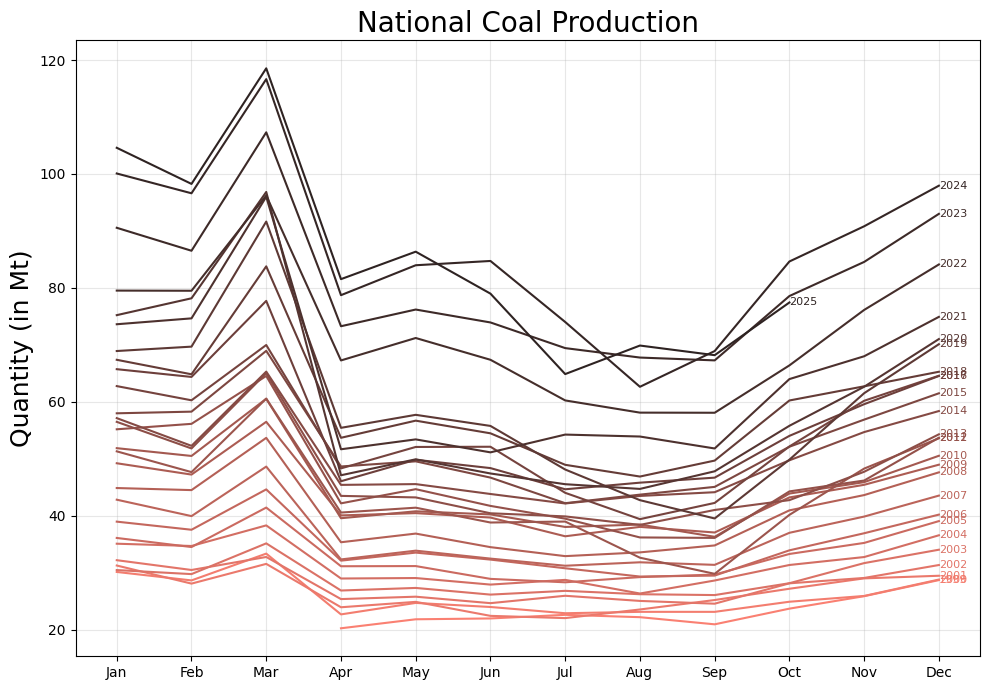

In [97]:
import seaborn as sns
palette = sns.color_palette("dark:salmon_r",len(df.year.unique()))
plt.figure(figsize=(10, 7))
for idx, year in enumerate(df.year.unique()):
    df_temp = df[df.year==year]
    plt.plot(df_temp['month'],df_temp['National coal production'], color=palette[idx])

        # add label at end of line
    plt.text(df_temp.dropna(subset=['National coal production'])['month'].iloc[-1],
             df_temp['National coal production'].dropna().iloc[-1],
             str(year),
             fontsize=8,
             color=palette[idx],
             va='center')
 

plt.title('National Coal Production', fontsize=20)
plt.ylabel('Quantity (in Mt)', fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.show()
plt.savefig('national_coal_production_months.png',dpi=300)

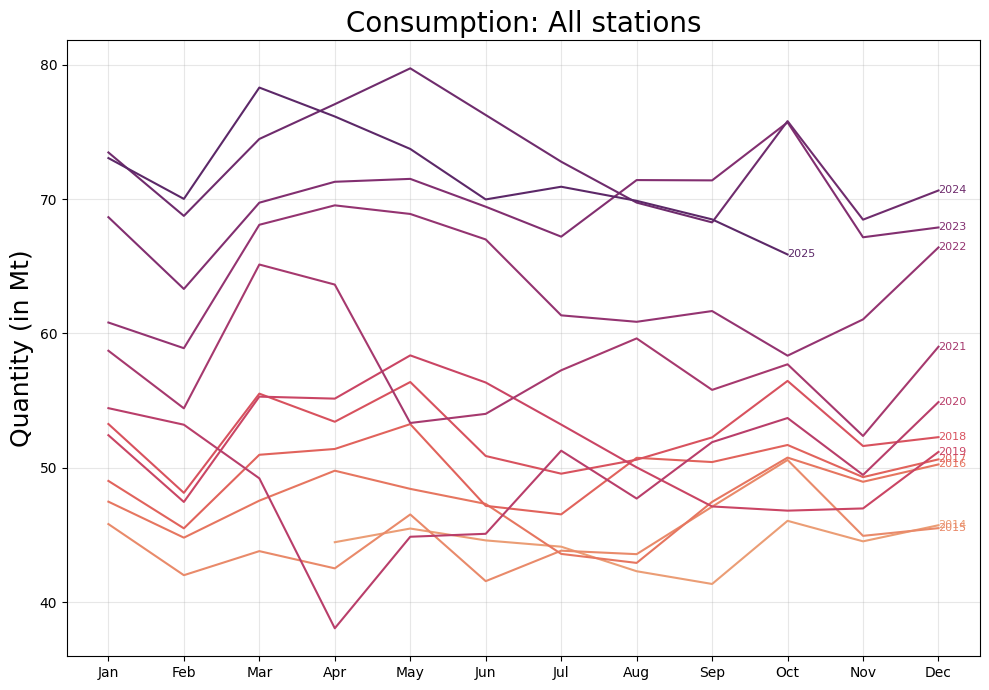

In [126]:
import seaborn as sns
palette = sns.color_palette("flare",len(df_yearly[df_yearly['Consumption: All stations']!=0].year.unique()))
plt.figure(figsize=(10, 7))
for idx, year in enumerate(df_yearly[df_yearly['Consumption: All stations']!=0].year.unique()):
    df_temp = df[df.year==year]
    if df_temp.dropna(subset=['Consumption: All stations']).shape[0] == 0:
        continue
    
    plt.plot(df_temp['month'],df_temp['Consumption: All stations'], color=palette[idx])

        # add label at end of line
    plt.text(df_temp.dropna(subset=['Consumption: All stations'])['month'].iloc[-1],
             df_temp['Consumption: All stations'].dropna().iloc[-1],
             str(year),
             fontsize=8,
             color=palette[idx],
             va='center')
 

plt.title('Consumption: All stations', fontsize=20)
plt.ylabel('Quantity (in Mt)', fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.show()
plt.savefig('national_coal_consumption_months.png',dpi=300)

In [106]:
df_temp['Consumption: All stations'].dropna().iloc[-1]

np.float64(65.877932)

In [109]:
df_temp

,YYYYMM,National coal production,Lignite production,CIL production,SCCL production,Net Imports,Power station stocks,Consumption: All stations,CIL despatches,year,month
0,1999-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,Jan
1,1999-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,Feb
2,1999-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,Mar
3,1999-04-01,20.230,2.093,17.420,NaN,NaN,NaN,NaN,21.460,1999,Apr
4,1999-05-01,21.809,1.804,18.931,NaN,NaN,NaN,NaN,22.355,1999,May
5,1999-06-01,21.955,1.648,18.970,NaN,NaN,NaN,NaN,21.561,1999,Jun
6,1999-07-01,22.591,1.680,19.476,NaN,NaN,NaN,NaN,21.609,1999,Jul
7,1999-08-01,22.179,1.794,19.254,NaN,NaN,NaN,NaN,20.057,1999,Aug
8,1999-09-01,20.925,1.972,17.901,NaN,NaN,NaN,NaN,18.501,1999,Sep
9,1999-10-01,23.679,1.399,20.449,NaN,NaN,NaN,NaN,20.194,1999,Oct


In [111]:
df_temp.dropna(subset=['Consumption: All stations']).shape[0]

0

,year,National coal production,Lignite production,CIL production,SCCL production,Net Imports,Power station stocks,Consumption: All stations,CIL despatches
15,2014,601.939,46.114,485.597,51.602,195.617891,194.657343,398.542000,484.532
16,2015,631.442,44.131,525.290,60.538,208.662368,360.413000,537.644997,524.030
17,2016,647.975,45.328,540.828,59.554,206.113224,399.541000,569.211000,534.755
18,2017,667.224,45.889,560.286,60.914,200.448180,253.701000,596.564000,572.957
19,2018,714.459,45.559,595.990,65.590,230.874080,232.350560,630.336550,603.530
20,2019,710.890,43.047,582.880,65.560,251.329238,352.551110,620.313220,581.030
21,2020,722.047,37.284,606.500,49.920,219.516936,545.647660,593.746860,573.600
22,2021,767.218,44.716,617.100,64.430,220.369065,313.020079,690.984912,646.600
23,2022,864.045,47.237,688.100,65.750,235.603844,332.988367,762.889557,688.200
24,2023,968.287,42.783,756.100,69.560,254.309020,382.480820,834.713844,739.100
